# FAERS 2026Q1 — Signal Visualization & Analysis
Pharmacovigilance signal detection from FDA Adverse Event Reporting System.
397,224 cases | 1.7M drug records | 1.3M reaction records

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import os
os.chdir(r'C:\Users\James\Documents\GitHub\faers-pharmacovigilance')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from pipeline import FAERSParser, deduplicate_cases, SignalDetector

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

DATA_DIR = Path('data/raw/2026Q1')
OUT_DIR  = Path('data/figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


In [3]:
# ── Load & deduplicate ──────────────────────────────────────────────────────
parser = FAERSParser(DATA_DIR)
demo, drug, reac, outc = parser.load_all()
demo = deduplicate_cases(demo)

valid_ids = set(demo['PRIMARYID'])
drug = drug[drug['PRIMARYID'].isin(valid_ids)].copy()
reac = reac[reac['PRIMARYID'].isin(valid_ids)].copy()
outc = outc[outc['PRIMARYID'].isin(valid_ids)].copy()

drug['_drug'] = drug['PROD_AI'].str.upper().str.strip()
reac['_pt']   = reac['PT'].str.upper().str.strip()

print(f'{len(demo):,} cases | {len(drug):,} drug records | {len(reac):,} reactions')

397,224 cases | 1,703,210 drug records | 1,330,675 reactions


## 1. Database Overview

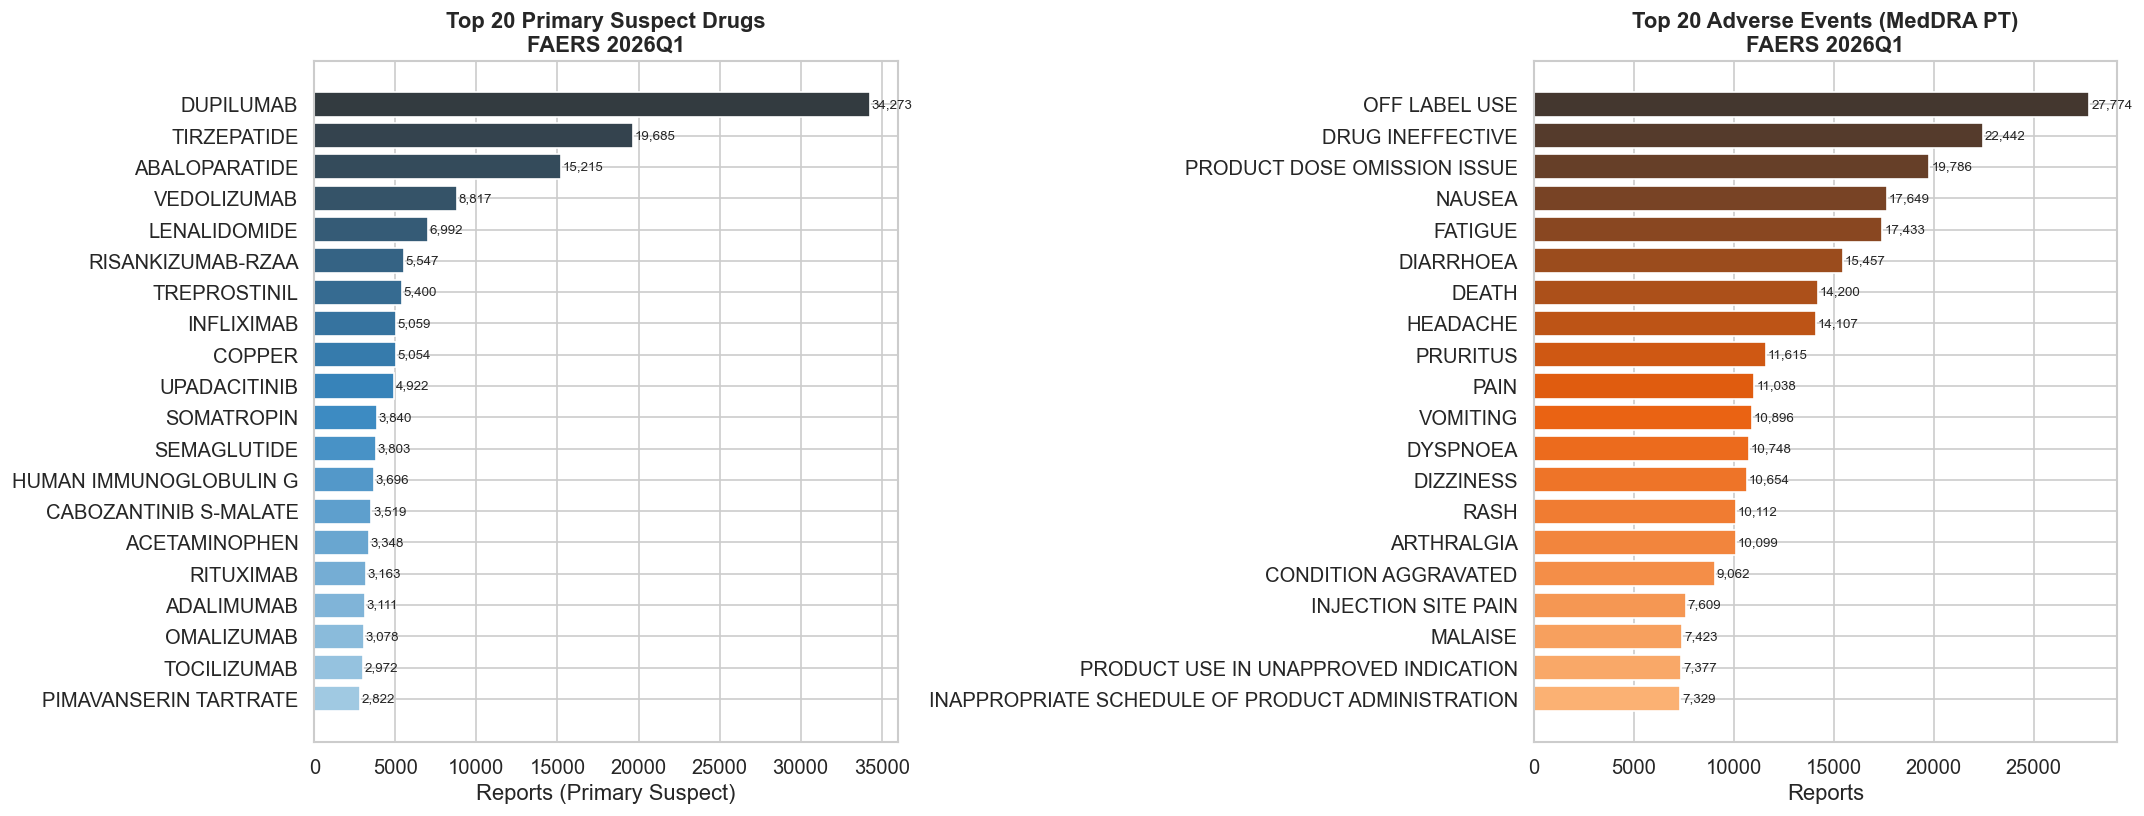

In [4]:
# ── Top 20 drugs & top 20 AEs side by side ──────────────────────────────────
top_drugs = (drug[drug['ROLE_COD']=='PS']['_drug']
             .value_counts().head(20))
top_aes   = reac['_pt'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Drugs
bars = axes[0].barh(top_drugs.index[::-1], top_drugs.values[::-1],
                    color=sns.color_palette('Blues_d', 20))
axes[0].set_xlabel('Reports (Primary Suspect)')
axes[0].set_title('Top 20 Primary Suspect Drugs\nFAERS 2026Q1', fontweight='bold')
for bar, val in zip(bars, top_drugs.values[::-1]):
    axes[0].text(val + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

# AEs
bars2 = axes[1].barh(top_aes.index[::-1], top_aes.values[::-1],
                     color=sns.color_palette('Oranges_d', 20))
axes[1].set_xlabel('Reports')
axes[1].set_title('Top 20 Adverse Events (MedDRA PT)\nFAERS 2026Q1', fontweight='bold')
for bar, val in zip(bars2, top_aes.values[::-1]):
    axes[1].text(val + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / '01_top_drugs_aes.png')
plt.show()

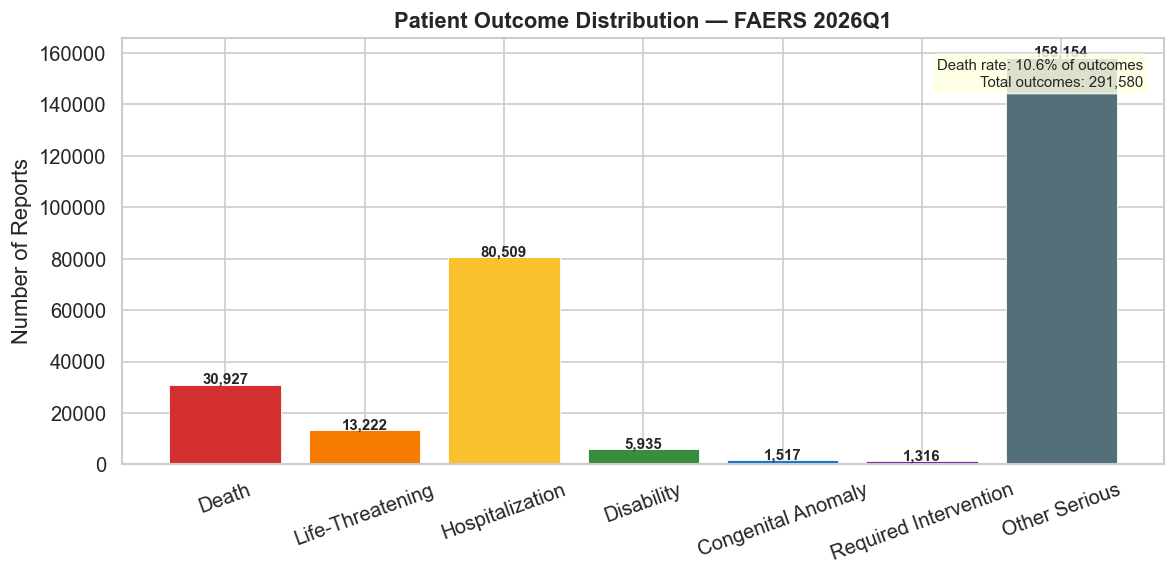

In [5]:
# ── Outcome distribution ─────────────────────────────────────────────────────
outcome_labels = {
    'DE': 'Death', 'LT': 'Life-Threatening', 'HO': 'Hospitalization',
    'DS': 'Disability', 'CA': 'Congenital Anomaly',
    'RI': 'Required Intervention', 'OT': 'Other Serious'
}
outc_counts = (outc['OUTC_COD'].map(outcome_labels)
               .value_counts()
               .reindex(outcome_labels.values())
               .dropna())

colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2','#7b1fa2','#546e7a']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(outc_counts.index, outc_counts.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Number of Reports')
ax.set_title('Patient Outcome Distribution — FAERS 2026Q1', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, outc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')

total = outc_counts.sum()
death_pct = outc_counts.get('Death', 0) / total * 100
ax.text(0.98, 0.95, f"Death rate: {death_pct:.1f}% of outcomes\nTotal outcomes: {total:,}",
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / '02_outcome_distribution.png')
plt.show()

## 2. Signal Detection — Dupilumab

In [6]:
# ── Run all three methods ────────────────────────────────────────────────────
DRUG_TARGET = 'DUPILUMAB'

detector = SignalDetector(drug, reac, drug_col='PROD_AI')
signals  = detector.run_all(DRUG_TARGET, min_reports=5, signal_any=False)

print(f'{len(signals)} AEs with ≥5 reports for {DRUG_TARGET}')
print(f'Signals flagged by all 3 methods: {(signals["SIGNAL_COUNT"]==3).sum()}')
print(f'Signals flagged by ≥1 method:     {(signals["SIGNAL_COUNT"]>=1).sum()}')
signals.head(10)

887 AEs with ≥5 reports for DUPILUMAB
Signals flagged by all 3 methods: 126
Signals flagged by ≥1 method:     242


,PT,a,N,ROR,ROR_CI_lo,ROR_CI_hi,ROR_signal,PRR,PRR_chi2,PRR_p,PRR_signal,EBGM,EB05,EB95,IC,EBGM_signal,SIGNAL_COUNT
0,DRY SKIN,2089,397209,13.248478,12.431467,14.119184,True,12.472900,10454.560718,0.000000e+00,True,6.378622,6.153156,6.612349,2.673245,True,3
1,OCULAR HYPERAEMIA,381,397209,4.282315,3.803044,4.821986,True,4.244409,684.859072,5.864753e-151,True,3.333210,3.063981,3.626095,1.736912,True,3
2,INJECTION SITE URTICARIA,265,397209,7.477356,6.396526,8.740816,True,7.425327,882.373962,6.661185e-194,True,4.806771,4.345189,5.317387,2.265068,True,3
3,OCULAR SURFACE DISEASE,11,397209,15.184619,6.107267,37.753823,True,15.179890,61.351748,4.773672e-15,True,5.533945,3.406948,8.988850,2.468308,True,3
4,ODYNOPHAGIA,34,397209,3.756414,2.545162,5.544103,True,3.753573,51.270663,8.046924e-13,True,2.966557,2.241934,3.925389,1.568790,True,3
5,OESOPHAGEAL FOOD IMPACTION,43,397209,47.532305,23.883890,94.595982,True,47.471656,369.141143,2.878687e-82,True,8.873888,6.915040,11.387626,3.149566,True,3
6,OFF LABEL USE OF DEVICE,13,397209,4.785457,2.495947,9.175114,True,4.783965,27.148725,1.883894e-07,True,3.315770,2.119071,5.188280,1.729344,True,3
7,INJECTION SITE INFLAMMATION,35,397209,4.394478,2.969831,6.502539,True,4.390877,65.592314,5.545461e-16,True,3.312799,2.513567,4.366161,1.728051,True,3
8,ORAL HERPES,159,397209,6.576680,5.403263,8.004926,True,6.549803,469.783850,3.571121e-104,True,4.434824,3.893216,5.051778,2.148877,True,3
9,OXYGEN CONSUMPTION INCREASED,17,397209,4.579372,2.601407,8.061273,True,4.577528,33.604950,6.752070e-09,True,3.291139,2.221102,4.876677,1.718587,True,3


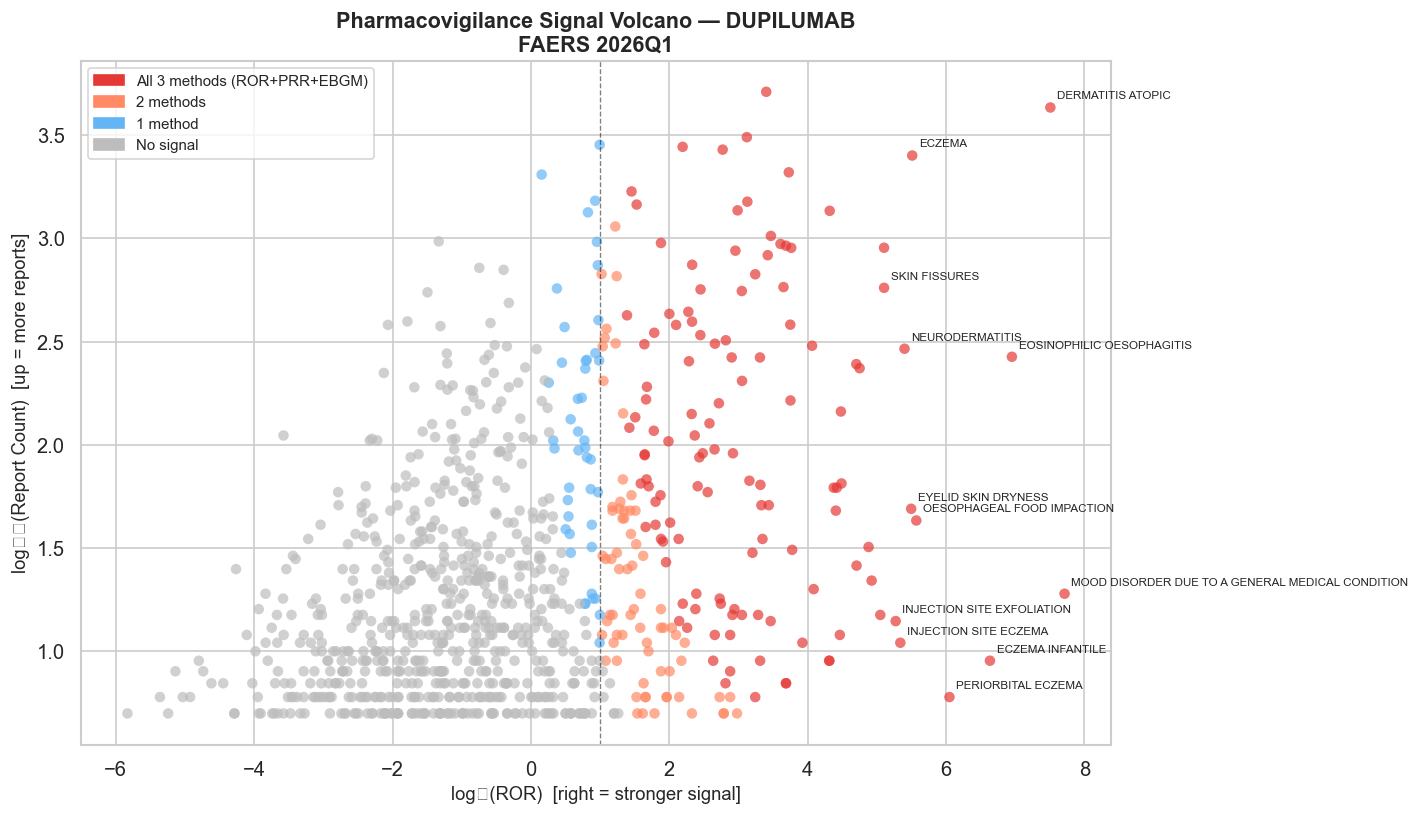

In [7]:
# ── Volcano plot: ROR vs report count ───────────────────────────────────────
# X = log2(ROR), Y = log10(report count), color = signal strength

plot_df = signals[(signals['ROR'] > 0) & (signals['ROR'] < 1000)].copy()
plot_df['log2_ROR'] = np.log2(plot_df['ROR'].clip(0.01))
plot_df['log10_n']  = np.log10(plot_df['a'].clip(1))

color_map = {0: '#bdbdbd', 1: '#64b5f6', 2: '#ff8a65', 3: '#e53935'}
colors_v  = plot_df['SIGNAL_COUNT'].map(color_map)

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(plot_df['log2_ROR'], plot_df['log10_n'],
           c=colors_v, alpha=0.7, s=40, linewidths=0)

# Label top signals
top = plot_df[plot_df['SIGNAL_COUNT']==3].nlargest(12, 'ROR')
for _, row in top.iterrows():
    ax.annotate(row['PT'], (row['log2_ROR'], row['log10_n']),
                fontsize=7, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.axvline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='ROR=2 threshold')
ax.set_xlabel('log₂(ROR)  [right = stronger signal]', fontsize=11)
ax.set_ylabel('log₁₀(Report Count)  [up = more reports]', fontsize=11)
ax.set_title(f'Pharmacovigilance Signal Volcano — {DRUG_TARGET}\nFAERS 2026Q1',
             fontweight='bold', fontsize=13)

legend_patches = [
    mpatches.Patch(color='#e53935', label='All 3 methods (ROR+PRR+EBGM)'),
    mpatches.Patch(color='#ff8a65', label='2 methods'),
    mpatches.Patch(color='#64b5f6', label='1 method'),
    mpatches.Patch(color='#bdbdbd', label='No signal'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / f'03_volcano_{DRUG_TARGET}.png')
plt.show()

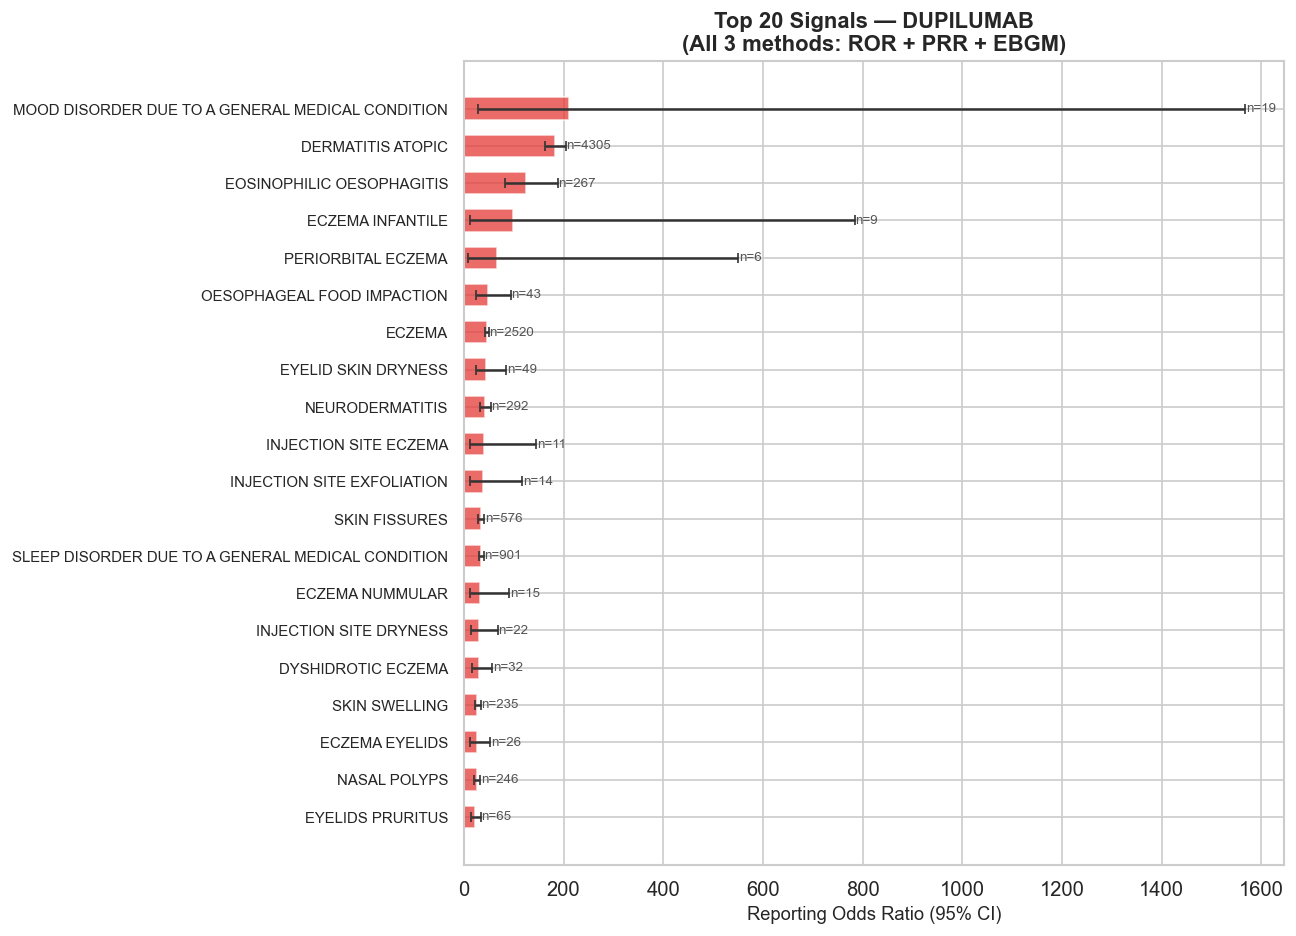

In [8]:
# ── Forest plot: top 20 signals by ROR ──────────────────────────────────────
forest_df = (signals[signals['SIGNAL_COUNT']==3]
             .nlargest(20, 'ROR')
             .sort_values('ROR'))

fig, ax = plt.subplots(figsize=(11, 8))
y_pos = range(len(forest_df))

ax.barh(list(y_pos), forest_df['ROR'], xerr=[
    forest_df['ROR'] - forest_df['ROR_CI_lo'],
    forest_df['ROR_CI_hi'] - forest_df['ROR']
], color='#e53935', alpha=0.75, ecolor='#333', capsize=3, height=0.6)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(forest_df['PT'], fontsize=9)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Reporting Odds Ratio (95% CI)', fontsize=11)
ax.set_title(f'Top 20 Signals — {DRUG_TARGET}\n(All 3 methods: ROR + PRR + EBGM)',
             fontweight='bold')

# Annotate with report count
for i, (_, row) in enumerate(forest_df.iterrows()):
    ax.text(row['ROR_CI_hi'] + 1, i, f"n={int(row['a'])}",
            va='center', fontsize=8, color='#555')

plt.tight_layout()
plt.savefig(OUT_DIR / f'04_forest_{DRUG_TARGET}.png')
plt.show()

## 3. Death-Associated Drug Ranking

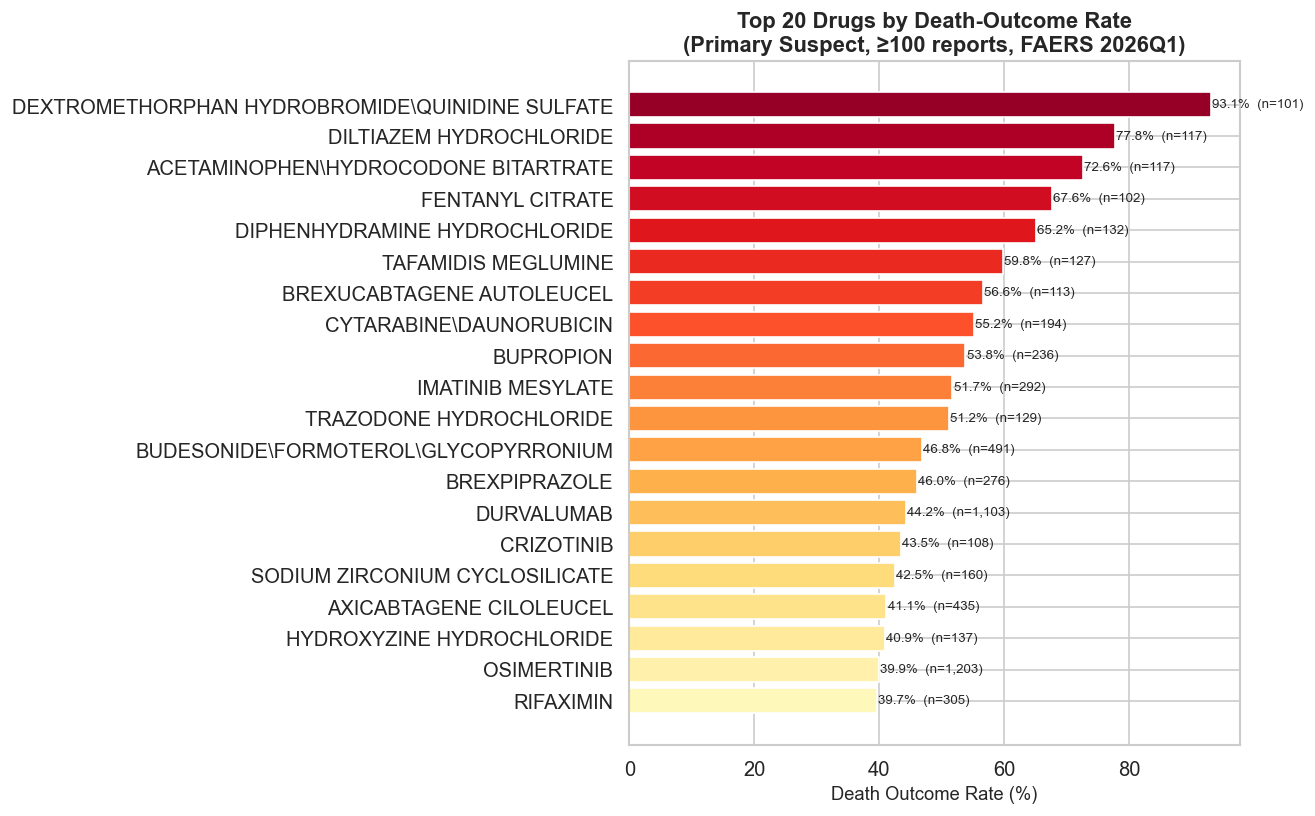

In [9]:
# ── Which drugs have highest death-outcome rate? ─────────────────────────────
death_cases = set(outc[outc['OUTC_COD']=='DE']['PRIMARYID'])

ps_drug = drug[drug['ROLE_COD']=='PS'][['PRIMARYID','_drug']].drop_duplicates()
ps_drug['death'] = ps_drug['PRIMARYID'].isin(death_cases).astype(int)

death_stats = (ps_drug.groupby('_drug')
               .agg(total=('PRIMARYID','count'), deaths=('death','sum'))
               .query('total >= 100')   # min 100 reports for stability
               .assign(death_rate=lambda x: x['deaths']/x['total']*100)
               .nlargest(20, 'death_rate')
               .sort_values('death_rate'))

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(death_stats.index, death_stats['death_rate'],
               color=sns.color_palette('YlOrRd', len(death_stats)))
ax.set_xlabel('Death Outcome Rate (%)', fontsize=11)
ax.set_title('Top 20 Drugs by Death-Outcome Rate\n(Primary Suspect, ≥100 reports, FAERS 2026Q1)',
             fontweight='bold')

for bar, (_, row) in zip(bars, death_stats.iterrows()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{row['death_rate']:.1f}%  (n={int(row['total']):,})",
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / '05_death_rate_by_drug.png')
plt.show()

## 4. Reporter & Demographics Profile

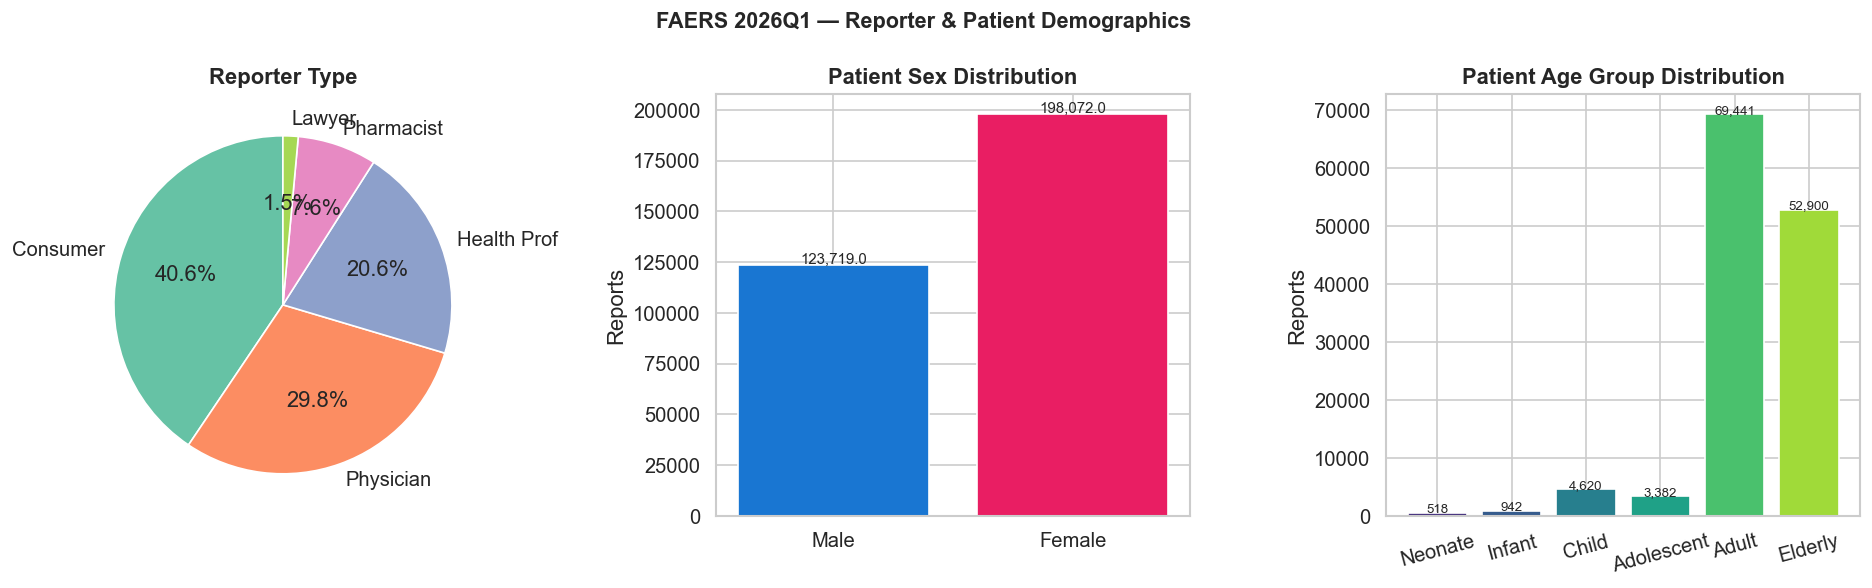

In [10]:
# ── Reporter type, sex distribution, age group ───────────────────────────────
occp_labels = {'MD':'Physician','PH':'Pharmacist','HP':'Health Prof',
               'CN':'Consumer','LW':'Lawyer','OT':'Other'}
sex_labels  = {'M':'Male','F':'Female','UNK':'Unknown'}
age_labels  = {'N':'Neonate','I':'Infant','C':'Child','T':'Adolescent',
               'A':'Adult','E':'Elderly'}

occp = demo['OCCP_COD'].map(occp_labels).value_counts()
sex  = demo['SEX'].map(sex_labels).value_counts().reindex(['Male','Female','Unknown']).dropna()
age  = demo['AGE_GRP'].map(age_labels).value_counts().reindex(age_labels.values()).dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Reporter type
axes[0].pie(occp.values, labels=occp.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[0].set_title('Reporter Type', fontweight='bold')

# Sex
axes[1].bar(sex.index, sex.values,
            color=['#1976d2','#e91e63','#9e9e9e'])
axes[1].set_title('Patient Sex Distribution', fontweight='bold')
axes[1].set_ylabel('Reports')
for i, (label, val) in enumerate(sex.items()):
    axes[1].text(i, val + 500, f'{val:,}', ha='center', fontsize=9)

# Age group (excluding null)
axes[2].bar(age.index, age.values,
            color=sns.color_palette('viridis', len(age)))
axes[2].set_title('Patient Age Group Distribution', fontweight='bold')
axes[2].set_ylabel('Reports')
axes[2].tick_params(axis='x', rotation=15)
for i, (label, val) in enumerate(age.items()):
    axes[2].text(i, val + 50, f'{val:,}', ha='center', fontsize=8)

fig.suptitle('FAERS 2026Q1 — Reporter & Patient Demographics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '06_demographics.png')
plt.show()

In [11]:
# ── Summary ──────────────────────────────────────────────────────────────────
print('=== Analysis Complete ===')
print(f'Figures saved to: {OUT_DIR.resolve()}')
for f in sorted(OUT_DIR.glob('*.png')):
    print(f'  {f.name}')

=== Analysis Complete ===
Figures saved to: C:\Users\James\Documents\GitHub\faers-pharmacovigilance\data\figures
  01_top_drugs_aes.png
  02_outcome_distribution.png
  03_volcano_DUPILUMAB.png
  04_forest_DUPILUMAB.png
  05_death_rate_by_drug.png
  06_demographics.png
